In [1]:
# load the pdf 
import fitz
import os 

doc = fitz.open("Data/rag_paper.pdf")
os.makedirs("pages" , exist_ok = True)

for page_num , page in enumerate(doc):
    #render page as image
    pix = page.get_pixmap(dpi = 150)
    pix.save(f"pages/page_{page_num}.png")
    
    # extract text from the same page
    text = page.get_text()
    with open(f"pages/page_{page_num}.txt" , "w") as f:
        f.write(text)

In [2]:
# load the embedding model
from transformers import AutoProcessor , AutoModel
from transformers.image_utils import load_image
import torch

modality = "image"
model_name = "nvidia/llama-nemotron-embed-vl-1b-v2"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModel.from_pretrained(
    model_name,
    dtype = torch.float16,
    trust_remote_code = True,
    attn_implementation = "flash_attention_2",
    device_map = "auto"
).eval()

model.safetensors:   0%|          | 0.00/3.36G [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/549 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

In [18]:
modality = "image_text"

# Max number of tokens based on modality
if modality == "image":
    p_max_length = 2048
elif modality == "image_text":
    p_max_length = 10240
elif modality == "text":
    p_max_length = 8192

model.processor.p_max_length = p_max_length
# Sets max number of tiles an image can be split. Each tile consumes 256 tokens.
model.processor.max_input_tiles = 6
# enable an extra tile with the full image at lower
model.processor.use_thumbnail = True

In [19]:
# load one sample image
from pathlib import Path
image_paths = [
    "./pages/page_0.png",
    "./pages/page_1.png"
]
images = [load_image(image_path) for image_path in image_paths]

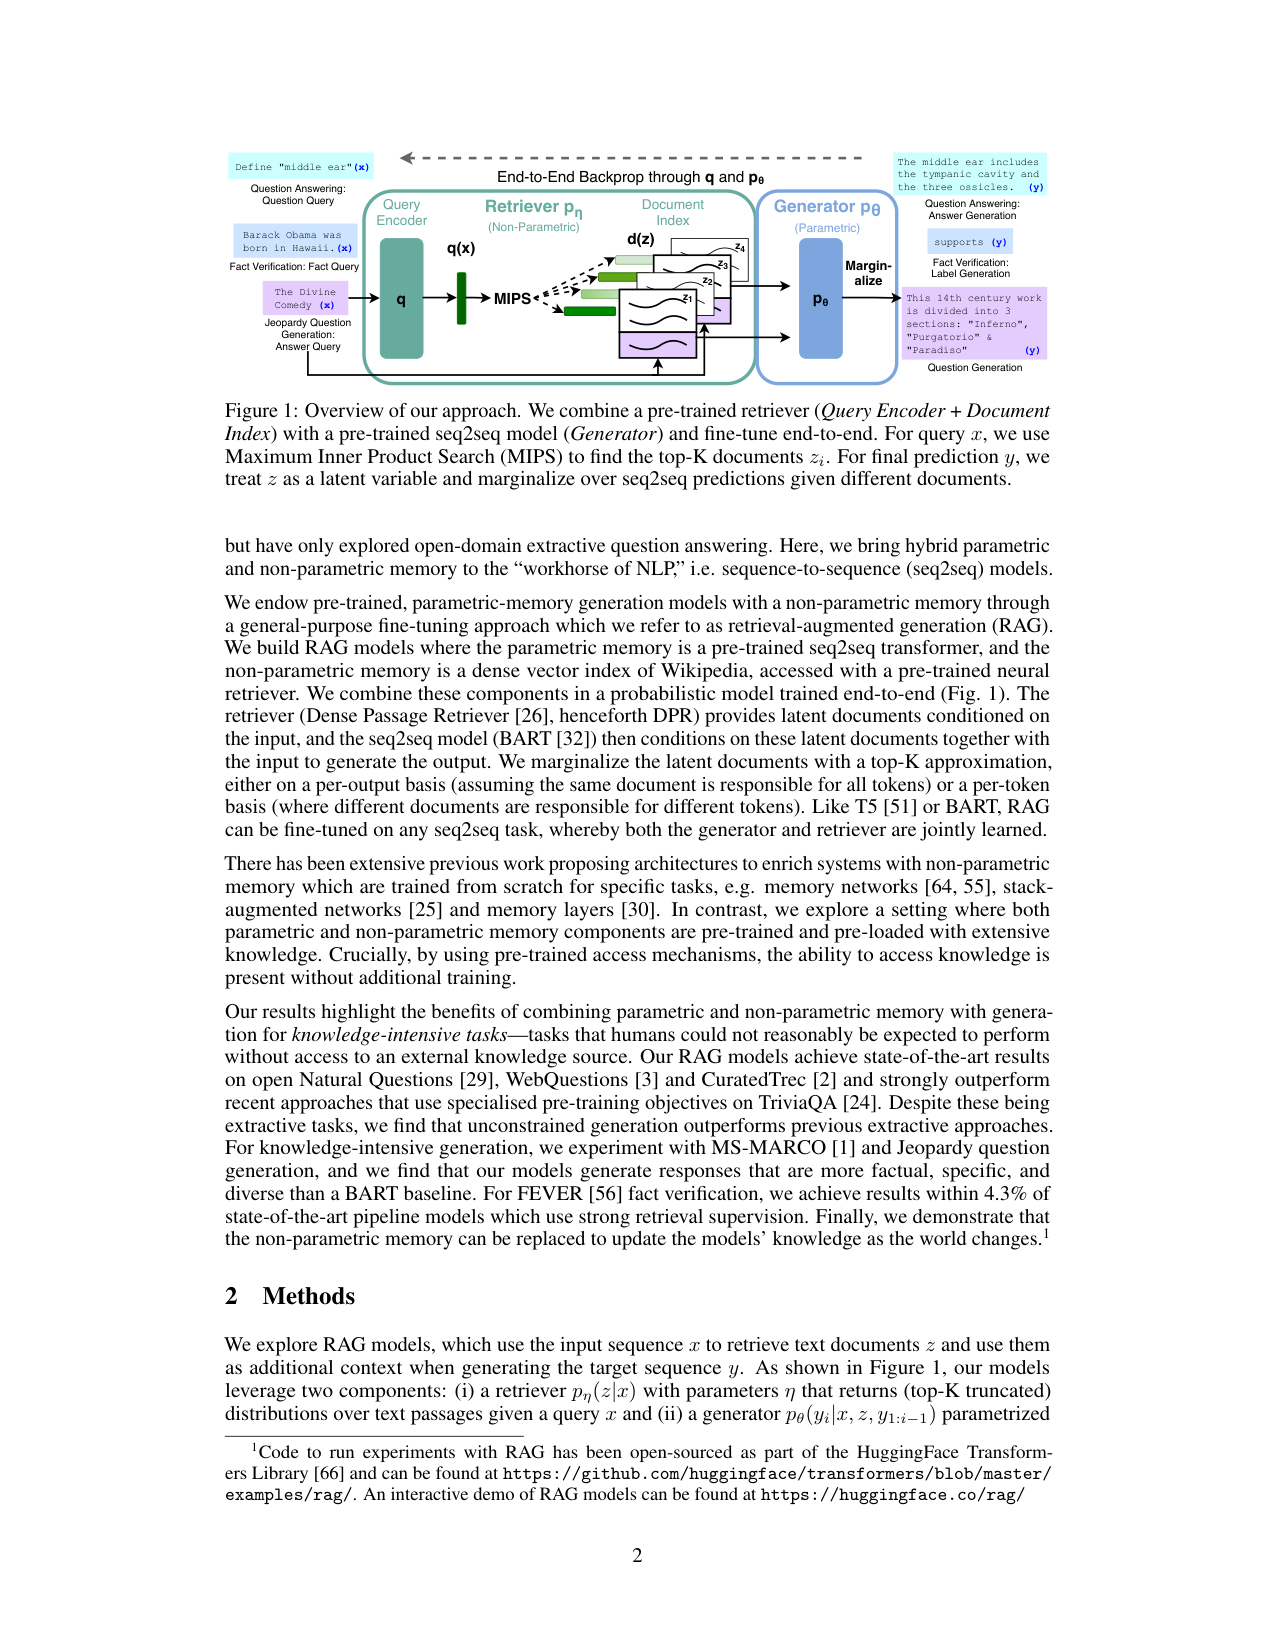

In [20]:
images[1]

In [21]:
doc_file_paths = [
    "./pages/page_0.txt",
    "./pages/page_1.txt",
]
documents = []
for path in doc_file_paths:
    with open(path, "r", encoding="utf-8") as f:
        documents.append(f.read())

In [22]:
query = "which model combine parametric memory with non-parametric memory?"

In [23]:
# run inference
with torch.inference_mode():
    queries_embeddings = model.encode_queries([query])
    
    if modality == "image_text":
        documents_embeddings = model.encode_documents(images=images, texts=documents)
    elif modality == "image":
        documents_embeddings = model.encode_documents(images=images)
    elif modality == "text":
        documents_embeddings = model.encode_documents(texts=documents)

In [24]:
queries_embeddings.shape

torch.Size([1, 2048])

In [25]:
def _l2_normalize(x: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    return x / (x.norm(p=2, dim=-1, keepdim=True) + eps)      

In [26]:
# compute cosine similarity between query embedding and documents embeddings
cos_sim = _l2_normalize(queries_embeddings) @ _l2_normalize(documents_embeddings).T

In [27]:
cos_sim # giving more similary with page-1 images, although we take the query from page-0

tensor([[0.3926, 0.4121]], device='cuda:0', dtype=torch.float16)

In [28]:
# Flatten logits to 1D array (handle both [batch_size] and [batch_size, 1] shapes)
cos_sim_flat = cos_sim.flatten()
cos_sim_flat

tensor([0.3926, 0.4121], device='cuda:0', dtype=torch.float16)

In [29]:
sorted_indices = torch.argsort(cos_sim_flat , descending = True)
sorted_indices

tensor([1, 0], device='cuda:0')

In [30]:
print(f"\nQuery: {query}\n")
print(f"\nRanking (highest to lowest relevance for the modality {modality}):")
for rank, idx in enumerate(sorted_indices, 1):
    doc_idx = idx.item()
    sim_val = cos_sim_flat[doc_idx].item()
    if modality == "text":
        print(f"  Rank {rank}: cos_sim={sim_val:.4f} | Text: {documents[doc_idx]}")
    else:  # image or image_text modality
        print(f"  Rank {rank}: cos_sim={sim_val:.4f} | Image: {image_paths[doc_idx]}")


Query: which model combine parametric memory with non-parametric memory?


Ranking (highest to lowest relevance for the modality image_text):
  Rank 1: cos_sim=0.4121 | Image: ./pages/page_1.png
  Rank 2: cos_sim=0.3926 | Image: ./pages/page_0.png
